In [ ]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pickle
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from tqdm import tqdm

# =====================================================
# 1️⃣ CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

OUTPUT_DIR = "/home/sunkari/Stock_price_predictor/Transformer/windows_new"
MODEL_PATH = "bilstm_model.pt"
BATCH_SIZE = 64
EPOCHS = 250
GRAD_CLIP = 0.5
LEARNING_RATE = 5e-5  
DROPOUT = 0.1

# =====================================================
# 2️⃣ LOAD PREPROCESSED TRAIN DATA
# =====================================================
train = pickle.load(open(os.path.join(OUTPUT_DIR, "train_windows.pkl"), "rb"))
companies = pickle.load(open(os.path.join(OUTPUT_DIR, "train_company_list.pkl"), "rb"))
print("✅ Loaded 'train_windows.pkl' and 'train_company_list.pkl'.")

# =====================================================
# 3️⃣ ENCODE COMPANY LABELS & SCALE TARGETS
# =====================================================
enc = LabelEncoder().fit(companies)
train_encoded = []
y_scalers = {}

for X, next_s, y, company in train:
    company_idx = enc.transform([company])[0]

    if company not in y_scalers:
        y_scaler = MinMaxScaler()
        company_y = [yi for _, _, yi, c in train if c == company]
        y_scaler.fit(np.array(company_y).reshape(-1,1))
        y_scalers[company] = y_scaler
    else:
        y_scaler = y_scalers[company]

    y_scaled = y_scaler.transform(np.array([[y]]))[0,0]
    train_encoded.append((X, next_s, y_scaled, company_idx))

num_companies = len(enc.classes_)
print(f"✅ Encoded companies | num_companies={num_companies}")

# =====================================================
# 4️⃣ DEFINE DATASET
# =====================================================
class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        X, next_sent, y, c = self.data[idx]
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
        next_sent = np.nan_to_num(next_sent, nan=0.0, posinf=0.0, neginf=0.0)
        y = 0.0 if not np.isfinite(y) else y

        company_feat = np.zeros(num_companies, dtype=np.float32)
        company_feat[c] = 1.0

        return (
            torch.tensor(X, dtype=torch.float32),
            torch.tensor(next_sent, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(company_feat, dtype=torch.float32)
        )

train_loader = DataLoader(WindowDataset(train_encoded), batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
print(f"✅ Training samples loaded: {len(train_loader.dataset)}")

# =====================================================
# 5️⃣ DEFINE BILSTM MODEL
# =====================================================
class StockBiLSTM(nn.Module):
    def __init__(self, feature_dim, sentiment_dim, company_feature_dim, hidden_dim=128, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_dim = feature_dim + company_feature_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = True

        self.lstm = nn.LSTM(
            input_size=self.input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=self.bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.sentiment_proj = nn.Linear(sentiment_dim, 32)

        lstm_output_dim = hidden_dim * 2 if self.bidirectional else hidden_dim
        self.fc = nn.Sequential(
            nn.Linear(lstm_output_dim + 32, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x, next_sent, company_feat):
        company_feat_exp = company_feat.unsqueeze(1).expand(-1, x.size(1), -1)
        x = torch.cat([x, company_feat_exp], dim=-1)

        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout(lstm_out)

        seq_out = lstm_out[:, -1, :]
        sent_embed = self.sentiment_proj(next_sent)
        combined = torch.cat([seq_out, sent_embed], dim=-1)
        return self.fc(combined).squeeze(-1)

# =====================================================
# 6️⃣ INITIALIZE MODEL, OPTIMIZER, LOSS
# =====================================================
feature_dim = train_encoded[0][0].shape[1]
sentiment_dim = train_encoded[0][1].shape[0]

model = StockBiLSTM(feature_dim, sentiment_dim, num_companies, hidden_dim=128, num_layers=2, dropout=DROPOUT).to(DEVICE)
opt = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
loss_fn = nn.SmoothL1Loss()  

print(f"✅ BiLSTM model initialized | feature_dim={feature_dim}, sentiment_dim={sentiment_dim}, companies={num_companies}")

# =====================================================
# 7️⃣ TRAINING LOOP
# =====================================================
for epoch in range(EPOCHS):
    model.train()
    total_loss, skipped = 0.0, 0

    for X, next_sent, y, c in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        X, next_sent, y, c = X.to(DEVICE), next_sent.to(DEVICE), y.to(DEVICE), c.to(DEVICE)
        opt.zero_grad()

        pred = model(X, next_sent, c)

        if torch.isnan(pred).any() or torch.isinf(pred).any():
            skipped += 1
            continue

        loss = loss_fn(pred, y)
        if torch.isnan(loss) or torch.isinf(loss):
            skipped += 1
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        opt.step()
        total_loss += loss.item()

    avg_loss = total_loss / (len(train_loader) - skipped + 1e-8)
    print(f"Epoch {epoch+1:03d} | Train Loss: {avg_loss:.6f} | Skipped: {skipped}")

# =====================================================
# 8️⃣ SAVE MODEL AND Y_SCALERS
# =====================================================
torch.save({
    "model_state": model.state_dict(),
    "companies": companies,
    "label_encoder": enc,
    "y_scalers": y_scalers
}, MODEL_PATH)

print(f"✅ BiLSTM model saved as '{MODEL_PATH}'")

🚀 Using device: cuda
✅ Loaded 'train_windows.pkl' and 'train_company_list.pkl'.
✅ Encoded companies | num_companies=8
✅ Training samples loaded: 7960
✅ BiLSTM model initialized | feature_dim=12, sentiment_dim=3, companies=8


Epoch 1/250: 100%|██████████| 125/125 [00:02<00:00, 52.90it/s]


Epoch 001 | Train Loss: 0.062627 | Skipped: 0


Epoch 2/250: 100%|██████████| 125/125 [00:01<00:00, 70.18it/s]


Epoch 002 | Train Loss: 0.005280 | Skipped: 0


...

Epoch 248 | Train Loss: 0.000222 | Skipped: 0


Epoch 249/250: 100%|██████████| 125/125 [00:01<00:00, 87.09it/s]


Epoch 249 | Train Loss: 0.000224 | Skipped: 0


Epoch 250/250: 100%|██████████| 125/125 [00:01<00:00, 85.69it/s] 

Epoch 250 | Train Loss: 0.000224 | Skipped: 0
✅ BiLSTM model saved as 'bilstm_model.pt'


100%|██████████| 32/32 [00:00<00:00, 44.25it/s]


✅ Saved normalized results to ./results/predictions_normalized.csv
✅ Saved denormalized results to ./results/predictions_denormalized.csv

📊 Denormalized Test Results:
MAPE: 4.38%, MAE: 9.831440, R2: 0.982995, Directional Accuracy: 95.93%


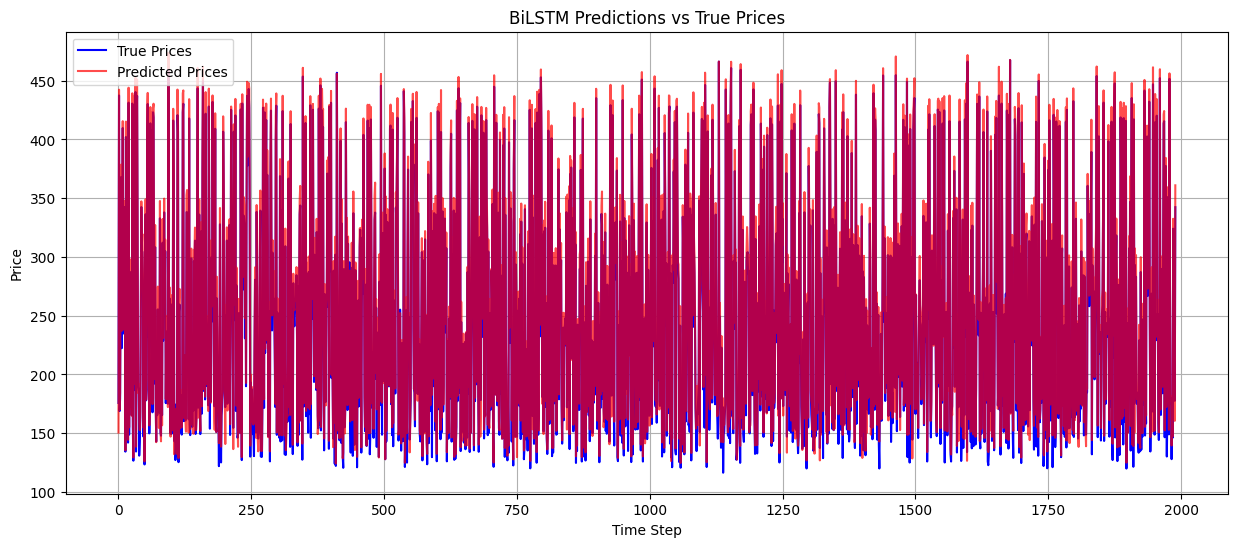

✅ Predictions saved to bilstm_predictions.csv


In [ ]:
import os
import pickle
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# =====================================================
# CONFIGURATION
# =====================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Using device: {DEVICE}")

TEST_PKL = "/home/sunkari/Stock_price_predictor/Transformer/windows_b/test_windows.pkl"
MODEL_PATH = "bilstm_model.pt"
SCALER_DIR = "/home/sunkari/Stock_price_predictor/Transformer/scaler_b"
BATCH_SIZE = 64

# =====================================================
# 1️⃣ LOAD TEST DATA
# =====================================================
with open(TEST_PKL, "rb") as f:
    test_data = pickle.load(f)
print(f"✅ Loaded {len(test_data)} test samples.")

# =====================================================
# 2️⃣ CREATE DATASET & DATALOADER
# =====================================================
class WindowDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x, y = self.data[idx][:2]
        company = self.data[idx][2] if len(self.data[idx]) == 3 else "unknown"
        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            company
        )

test_loader = DataLoader(WindowDataset(test_data), batch_size=BATCH_SIZE, shuffle=False)

# =====================================================
# 3️⃣ LOAD MODEL
# =====================================================
checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
input_size = checkpoint["input_size"]
hidden_size = checkpoint["hidden_size"]
num_layers = checkpoint["num_layers"]

class BiLSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True,
                            bidirectional=True)
        self.fc = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out).squeeze(-1)

model = BiLSTMRegressor(input_size, hidden_size, num_layers).to(DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print("✅ BiLSTM model loaded.")

# =====================================================
# 4️⃣ LOAD SCALERS
# =====================================================
scalers = {}
for scaler_file in os.listdir(SCALER_DIR):
    if scaler_file.endswith("_y_scaler.pkl"):
        company_name = scaler_file.replace("_y_scaler.pkl", "")
        with open(os.path.join(SCALER_DIR, scaler_file), "rb") as f:
            scalers[company_name] = pickle.load(f)

# =====================================================
# 5️⃣ PREDICTION LOOP
# =====================================================
all_targets, all_preds, all_companies = [], [], []

with torch.no_grad():
    for X_batch, y_batch, company_batch in tqdm(test_loader):
        X_batch = X_batch.to(DEVICE)
        preds = model(X_batch).cpu().numpy()
        y_batch = y_batch.numpy()

        for i in range(len(preds)):
            y_val = 0.0 if not np.isfinite(y_batch[i]) else y_batch[i]
            pred_val = 0.0 if not np.isfinite(preds[i]) else preds[i]

            company_name = company_batch[i] if company_batch[i] in scalers else None
            scaler = scalers.get(company_name, None)

            if scaler:
                # Safe inverse_transform
                y_true_denorm = scaler.inverse_transform(np.array([[y_val]]))[0][0]
                y_pred_denorm = scaler.inverse_transform(np.array([[pred_val]]))[0][0]
            else:
                y_true_denorm = y_val
                y_pred_denorm = pred_val

            all_targets.append(y_true_denorm)
            all_preds.append(y_pred_denorm)
            all_companies.append(company_name)

# =====================================================
# 6️⃣ EVALUATION METRICS
# =====================================================
all_targets_np = np.array(all_targets)
all_preds_np = np.array(all_preds)

mae = mean_absolute_error(all_targets_np, all_preds_np)
mask = all_targets_np != 0
mape = np.mean(np.abs((all_targets_np[mask] - all_preds_np[mask]) / all_targets_np[mask])) * 100
r2 = r2_score(all_targets_np, all_preds_np)

# Directional Accuracy
direction_correct = np.sum(np.diff(all_targets_np) * np.diff(all_preds_np) > 0)
directional_accuracy = direction_correct / (len(all_targets_np) - 1) * 100

print("\n📊 Test Metrics:")
print(f"MAE: {mae:.4f}, MAPE: {mape:.2f}%, R2: {r2:.4f}, Directional Accuracy: {directional_accuracy:.2f}%")

# =====================================================
# 7️⃣ PLOT TRUE VS PREDICTED
# =====================================================
plt.figure(figsize=(15,6))
plt.plot(all_targets_np, label="True Prices", color="blue")
plt.plot(all_preds_np, label="Predicted Prices", color="red", alpha=0.7)
plt.title("BiLSTM Predictions vs True Prices")
plt.xlabel("Time Step")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()
# =====================================================
# 8️⃣ SAVE RESULTS TO CSV
# =====================================================
results_df = pd.DataFrame({
    "Company": all_companies,
    "True_Price": all_targets_np,
    "Predicted_Price": all_preds_np
})

csv_path = "bilstm_predictions.csv"
results_df.to_csv(csv_path, index=False)
print(f"✅ Predictions saved to {csv_path}")